# Initial Data Analysis

## Overview:
1. [Loading data](#loading-data)
2. [Initial exploration](#initial-exploration)
3. [Target Variable & Train-Test Split](#Target-Variable-&-Train-Test-Split)
4. [Predictors analysis](#features-overview)
5. [Correlation analysis](#correlation-analysis)
6. [Feature selection](#feature-selection)

## Loading data
<a id="loading-data"></a>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv("data/raw/housing.csv")

# Initial exploration

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
print("Total number of rows: " + str(len(data)))

Total number of rows: 20640


In [6]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<b>Conclusion:</b> Quick dataset analysis provided information about data structure (numerical and categorical data), total length, column names, and data format. From this target variable can be indentified, and plan of action devised regarding the data transformation.


## Target Variable & Train-Test Split

Splitting the dataset into training and testing sets prevents data leakage. Setting random_state=142 ensures that the split is reproducible across the analysis and the ML pipeline. Using Scikit-Learn's built-in train_test_split method, 80% of the available data is allocated for training, while the remaining 20% is reserved for evaluation.

In [7]:
train_set, test_set = train_test_split(data, test_size=0.2, random_state=142)

In [8]:
train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16349.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.576060,35.639528,28.660792,2650.587694,540.908435,1431.202519,502.041606,3.874176,207096.552447
std,2.002628,2.133772,12.614448,2215.597732,429.925960,1155.299540,389.803155,1.897529,115463.056370
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.940000,18.000000,1451.000000,297.000000,788.000000,281.000000,2.566950,119475.000000
50%,-118.510000,34.260000,29.000000,2136.000000,435.000000,1166.500000,410.000000,3.537500,180400.000000
75%,-118.010000,37.710000,37.000000,3152.250000,646.000000,1725.250000,603.000000,4.740400,265300.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
print("Missing Values per column:")
missing_values = pd.DataFrame({
    'Missing_Count': train_set.isnull().sum(),
    'Missing_%': (train_set.isnull().mean() * 100).round(2)
})

missing_columns = missing_values[missing_values['Missing_Count'] > 0]
print(missing_columns)

Missing Values per column:
                Missing_Count  Missing_%
total_bedrooms            163       0.99


Observation: The total_bedrooms column in the training set has 163 missing values (roughly 1% of all records).

Conclusion: Unhandled missing values can degrade prediction accuracy and must be handled during preprocessing.

### Target variable: median_house_value

<Axes: >

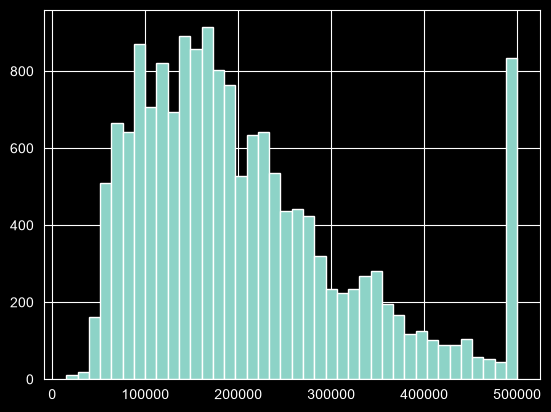

In [10]:
train_set['median_house_value'].hist(bins=40)

In [11]:
print(train_set['median_house_value'].describe().map("{:.3f}".format))

count     16512.000
mean     207096.552
std      115463.056
min       14999.000
25%      119475.000
50%      180400.000
75%      265300.000
max      500001.000
Name: median_house_value, dtype: str


Observation: The target variable is right-skewed and capped at 500,001 (introducing an artificial ceiling), which could negatively affect linear regression performance.

Conclusion: The capped records introduce a data quality issue that can be resolved by dropping the affected rows, while the skewness can be corrected using a transformation such as Box-Cox or Yeo-Johnson.

### Capped values

In [12]:
limit = 500000
capped = (train_set['median_house_value'] >= limit).sum()
print(f"% of rows capped: {(capped/len(train_set))*100:.2f}")

% of rows capped: 4.82


Conclusion: Fewer than 5% of rows are affected by the upper limit. Removing them retains over 95% of valid data.

In [13]:
train_set = train_set[train_set['median_house_value'] < limit].copy()
capped = (train_set['median_house_value'] >= limit).sum()
print(f"% of rows capped: {(capped/len(train_set))*100:.2f}")

% of rows capped: 0.00


Result: Successfully removed all capped rows, retaining 95% of the dataset.

### Skewness

In [14]:
print(f"Target variable skewness: {train_set['median_house_value'].skew():.2f}")

Target variable skewness: 0.79


Observation: Value of 0.79 introduces moderate skewness. This can be improved by applying transformation

Improved target skewness: -0.02


<Axes: >

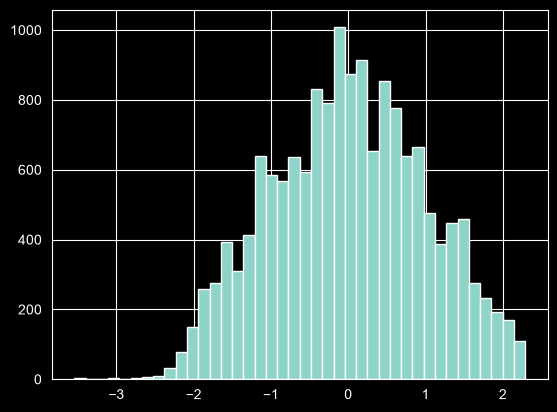

In [15]:
from sklearn.preprocessing import power_transform

train_set['box_median_house_value'] = power_transform(pd.DataFrame(train_set['median_house_value']), method='box-cox', standardize=True)
print(f"Improved target skewness: {train_set['box_median_house_value'].skew():.2f}")
train_set['box_median_house_value'].hist(bins=40)

Conclusion: Applying the Box-Cox transformation reduced skewness to -0.02, placing the target variable well within the threshold for an approximately symmetric distribution [-0.5, 0.5].

# Predictors analysis

<Figure size 1000x1000 with 0 Axes>

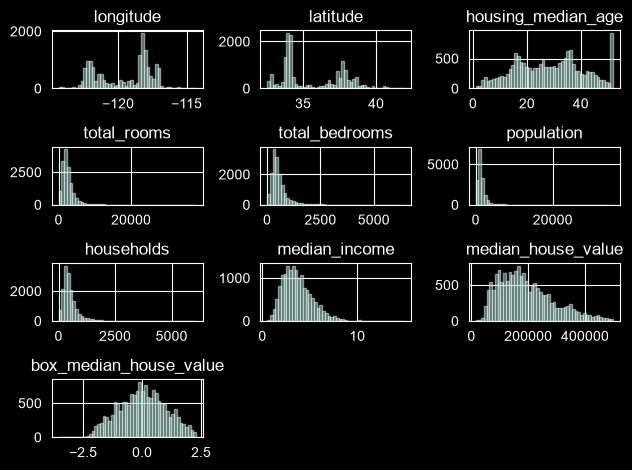

In [16]:
plt.figure(figsize=(10,10))
train_set.hist(alpha=0.5, bins=50)
plt.tight_layout()

Observation: A lot of features are right-skewed, while housing_median_age has capped values.

### Exploring total_bedrooms (missing values)

<Axes: >

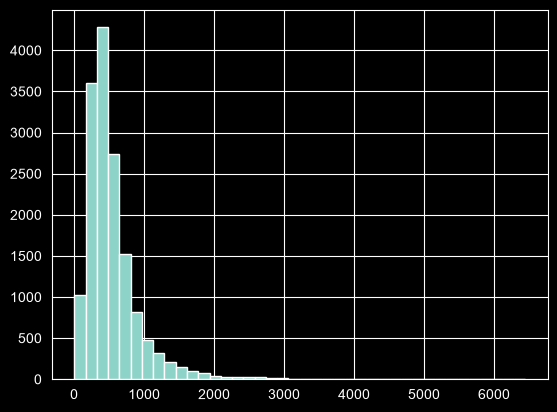

In [17]:
train_set['total_bedrooms'].hist(bins=40)

In [18]:
train_set.isna().sum()

longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms            159
population                  0
households                  0
median_income               0
median_house_value          0
ocean_proximity             0
box_median_house_value      0
dtype: int64

Observation: 159 rows in the total_bedrooms feature are missing.

Conclusion: Imputing these missing entries with the median value resolves the issue.

In [19]:
bedrooms_median_val = train_set['total_bedrooms'].median()
train_set.fillna({'total_bedrooms': bedrooms_median_val}, inplace=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,box_median_house_value
17758,-121.80,37.35,17.0,2529.0,423.0,1756.0,429.0,5.1017,240700.0,<1H OCEAN,0.644487
10223,-117.89,33.88,27.0,2091.0,336.0,1037.0,332.0,5.7519,243400.0,<1H OCEAN,0.667540
17443,-120.47,34.66,4.0,3376.0,525.0,1684.0,535.0,4.9237,166600.0,NEAR OCEAN,-0.082540
12965,-121.32,38.70,17.0,3214.0,551.0,1879.0,562.0,4.3643,124900.0,INLAND,-0.608829
20149,-119.12,34.38,28.0,7200.0,1281.0,3793.0,1238.0,4.0750,237900.0,<1H OCEAN,0.620372
...,...,...,...,...,...,...,...,...,...,...,...
5146,-118.26,33.96,39.0,1255.0,323.0,902.0,327.0,1.5812,94000.0,<1H OCEAN,-1.093786
7436,-118.19,33.94,45.0,1871.0,371.0,1315.0,382.0,3.3661,160800.0,<1H OCEAN,-0.149242
12799,-121.45,38.61,32.0,2436.0,612.0,1509.0,618.0,1.0424,81400.0,INLAND,-1.327091
7365,-118.20,33.96,44.0,3114.0,779.0,2959.0,776.0,3.1875,171700.0,<1H OCEAN,-0.025334


### Impossible data

In [20]:
invalid_rooms = train_set[train_set['total_bedrooms'] > train_set['total_rooms']]
print("Bedrooms > Total rooms count:", len(invalid_rooms))

Bedrooms > Total rooms count: 4


Observation: Four rows have more bedrooms than total rooms, representing an inconsistency in the data.

Conclusion: These four rows will be removed; given the negligible sample size, dropping them will not negatively affect model training.

In [21]:
train_set = train_set[train_set['total_bedrooms'] <= train_set['total_rooms']].copy()

Original skewness: 3.53
Transformed skewness: -0.94


<Axes: >

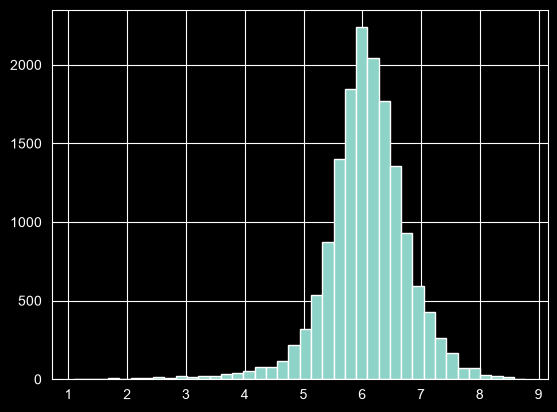

In [22]:
print(f"Original skewness: {train_set['total_bedrooms'].skew():.2f}")
train_set['log_total_bedrooms'] = np.log1p(train_set['total_bedrooms'])
print(f"Transformed skewness: {train_set['log_total_bedrooms'].skew():.2f}")

train_set['log_total_bedrooms'].hist(bins=40)

In [23]:
from sklearn.preprocessing import power_transform
train_set['yeo_total_bedrooms'] = power_transform(pd.DataFrame(train_set['total_bedrooms']),method='yeo-johnson',standardize=True)
print(f"Yeo-johnson transformation skewness: {train_set['yeo_total_bedrooms'].skew():.2f}")

Yeo-johnson transformation skewness: 0.11


<Axes: >

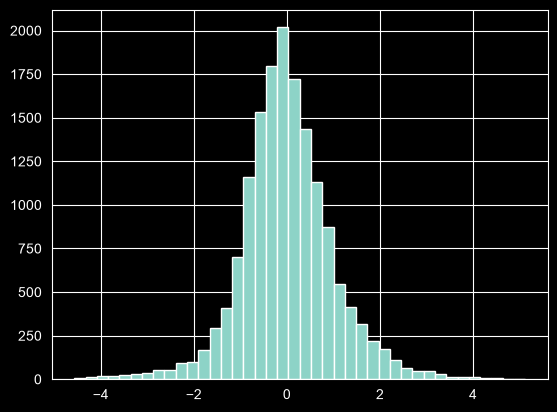

In [24]:
train_set['yeo_total_bedrooms'].hist(bins=40)

Conclusion: The Scikit-Learn transformation resulted in a more symmetrical data distribution.

## Exploring: Total rooms

<Axes: >

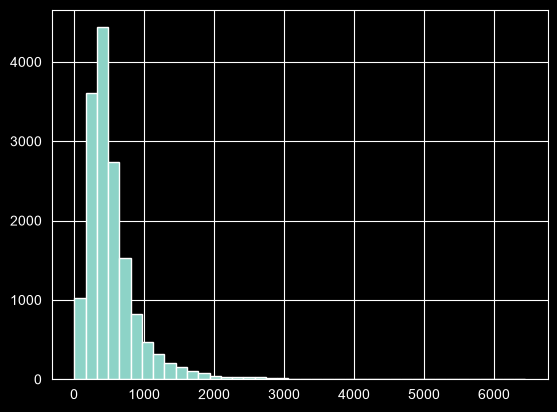

In [25]:
train_set['total_bedrooms'].hist(bins=40)

In [26]:
(train_set['total_rooms'] <= 0).sum()

np.int64(0)

Conclusion: There are no impossible data inside this feature.

4.20
0.12


<Axes: >

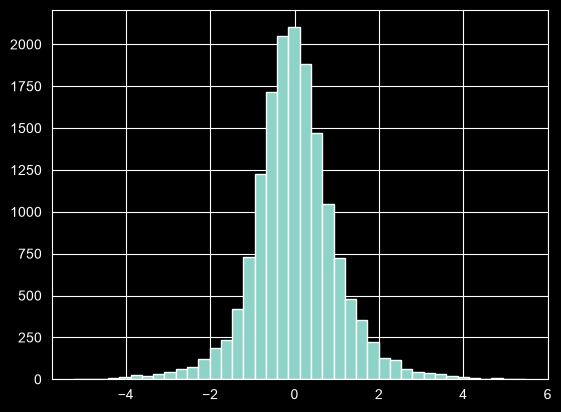

In [27]:
print(f"{train_set['total_rooms'].skew():.2f}")
train_set['box_total_rooms'] = power_transform(pd.DataFrame(train_set['total_rooms']),method='box-cox',standardize=True)
print(f"{train_set['box_total_rooms'].skew():.2f}")
train_set['box_total_rooms'].hist(bins=40)

## Exploring: Housing median age

<Axes: >

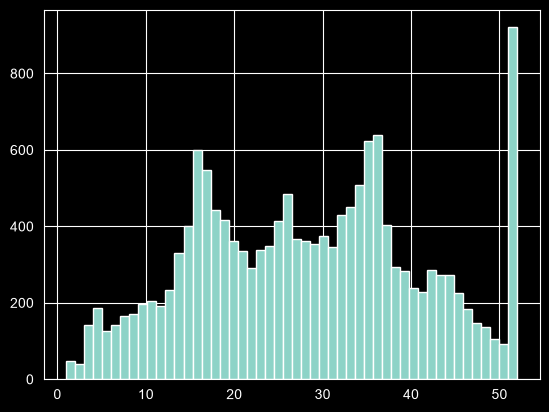

In [28]:
train_set['housing_median_age'].hist(bins=50)

Conclusion: The upper-bound values can be addressed by binning the feature or by introducing a binary flag to indicate capped records.

### Binning method

Consolidates continuous values into discrete bins and converts them into dummy variables, with each feature taking a value of 0 or 1.

<Axes: xlabel='age_category', ylabel='count'>

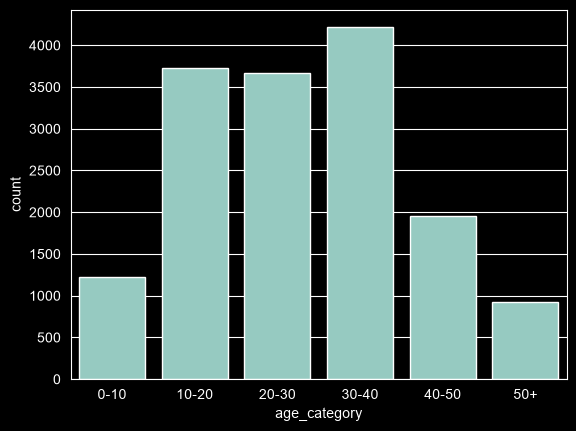

In [29]:
train_set['age_category'] = pd.cut(
    train_set['housing_median_age'],
    bins=[0,10,20,30,40,50,float('inf')],
    labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50+'])

import seaborn as sns
sns.countplot(data=train_set, x='age_category')

In [30]:
train_set = pd.get_dummies(
    train_set,
    columns=['age_category'],
    prefix='age',
    drop_first=True,
    dtype=int
)

In [31]:
train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,box_median_house_value,log_total_bedrooms,yeo_total_bedrooms,box_total_rooms,age_10-20,age_20-30,age_30-40,age_40-50,age_50+
17758,-121.80,37.35,17.0,2529.0,423.0,1756.0,429.0,5.1017,240700.0,<1H OCEAN,0.644487,6.049733,-0.095102,0.216394,1,0,0,0,0
10223,-117.89,33.88,27.0,2091.0,336.0,1037.0,332.0,5.7519,243400.0,<1H OCEAN,0.667540,5.820083,-0.416914,-0.054045,0,1,0,0,0
17443,-120.47,34.66,4.0,3376.0,525.0,1684.0,535.0,4.9237,166600.0,NEAR OCEAN,-0.082540,6.265301,0.220975,0.647881,0,0,0,0,0
12965,-121.32,38.70,17.0,3214.0,551.0,1879.0,562.0,4.3643,124900.0,INLAND,-0.608829,6.313548,0.293637,0.572610,1,0,0,0,0
20149,-119.12,34.38,28.0,7200.0,1281.0,3793.0,1238.0,4.0750,237900.0,<1H OCEAN,0.620372,7.156177,1.684821,1.908398,0,1,0,0,0


Conclusion: Removing the first bin resolves multicollinearity without losing information. If none of the remaining dummy features equal 1, the observation is understood to fall into this baseline bin.

### Boolean Flag
This approach handles the capping issue by introducing a binary indicator variable, assigning a value of 1 to capped records and 0 to all others.

In [32]:
max_age = train_set['housing_median_age'].max()
print((train_set['housing_median_age'] >= max_age).mean()*100)


5.626272912423625


In [33]:
train_set['is_age_capped'] = (train_set['housing_median_age'] >= max_age).astype(int)

# Feature engineering

Process of creating new features from existing predictors.

In [34]:
train_set['population_per_household'] = train_set['population']/train_set['households']
train_set['rooms_per_household'] = train_set['total_rooms']/train_set['households']
train_set['bedrooms_per_room'] = train_set['total_bedrooms']/train_set['total_rooms']


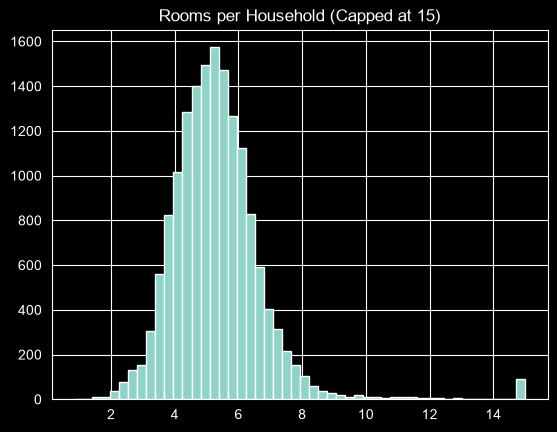

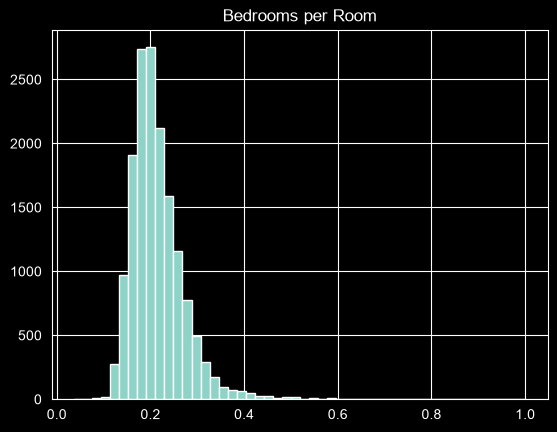

In [35]:
train_set['rooms_per_household'].clip(upper=15).hist(bins=50)
plt.title("Rooms per Household (Capped at 15)")
plt.show()

train_set['bedrooms_per_room'].hist(bins=50)
plt.title("Bedrooms per Room")
plt.show()

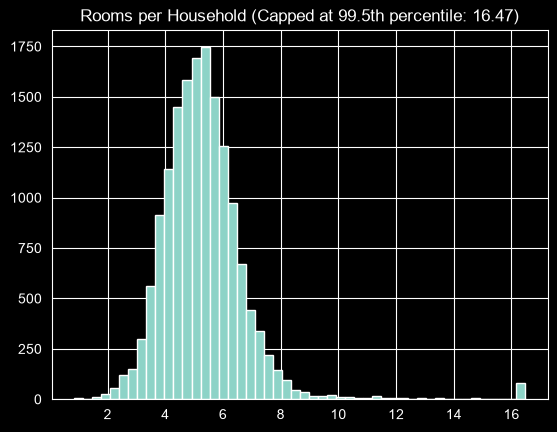

In [36]:

upper_limit = train_set['rooms_per_household'].quantile(0.995)
train_set['rooms_per_household_capped'] = train_set['rooms_per_household'].clip(upper=upper_limit)

train_set['rooms_per_household_capped'].hist(bins=50)
plt.title(f"Rooms per Household (Capped at 99.5th percentile: {upper_limit:.2f})")
plt.show()

## Categorical data

Observation: ocean_proximity is a categorical data with labels. To convert it to numerical data, the process of binning will convert each label into separate feature with value of 0 to 1

In [37]:
train_set = pd.get_dummies(
    train_set,
    columns=['ocean_proximity'],
    prefix='distance:',
    drop_first=True,
    dtype=int
)

In [38]:
train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,box_median_house_value,...,age_50+,is_age_capped,population_per_household,rooms_per_household,bedrooms_per_room,rooms_per_household_capped,distance:_INLAND,distance:_ISLAND,distance:_NEAR BAY,distance:_NEAR OCEAN
17758,-121.80,37.35,17.0,2529.0,423.0,1756.0,429.0,5.1017,240700.0,0.644487,...,0,0,4.093240,5.895105,0.167260,5.895105,0,0,0,0
10223,-117.89,33.88,27.0,2091.0,336.0,1037.0,332.0,5.7519,243400.0,0.667540,...,0,0,3.123494,6.298193,0.160689,6.298193,0,0,0,0
17443,-120.47,34.66,4.0,3376.0,525.0,1684.0,535.0,4.9237,166600.0,-0.082540,...,0,0,3.147664,6.310280,0.155509,6.310280,0,0,0,1
12965,-121.32,38.70,17.0,3214.0,551.0,1879.0,562.0,4.3643,124900.0,-0.608829,...,0,0,3.343416,5.718861,0.171437,5.718861,1,0,0,0
20149,-119.12,34.38,28.0,7200.0,1281.0,3793.0,1238.0,4.0750,237900.0,0.620372,...,0,0,3.063813,5.815832,0.177917,5.815832,0,0,0,0


## Latitude and longitude features

Observation: Applying direct transformations to either feature yields little useful information regarding the target variable.

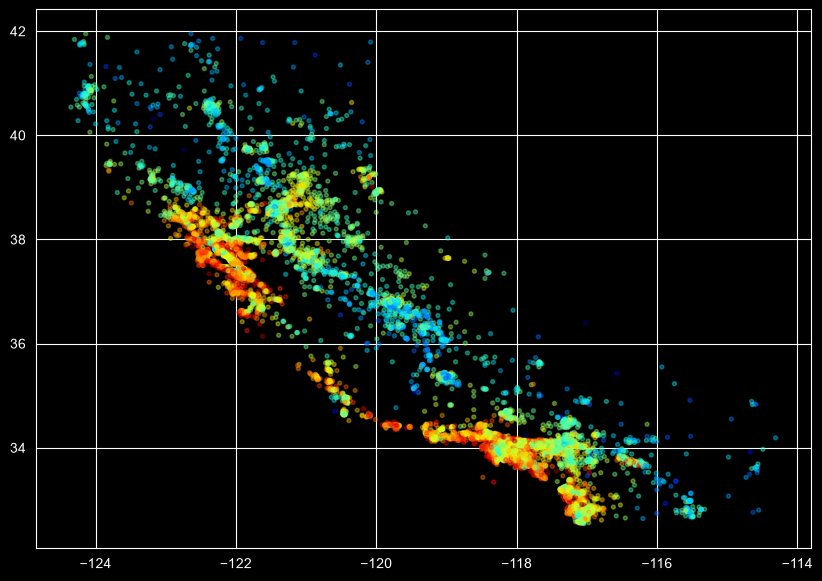

In [39]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    x=train_set['longitude'],
    y=train_set['latitude'],
    c=train_set['box_median_house_value'],
    cmap='jet',
    s=8,
    alpha=0.4
)

Conclusion: Areas closer to the coastline exhibit significantly higher median house values. By using a clustering algorithm, we can segment these expensive regions into discrete clusters and include them as an informative spatial feature.

In [40]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(train_set[['latitude', 'longitude']])

centers = kmeans.cluster_centers_

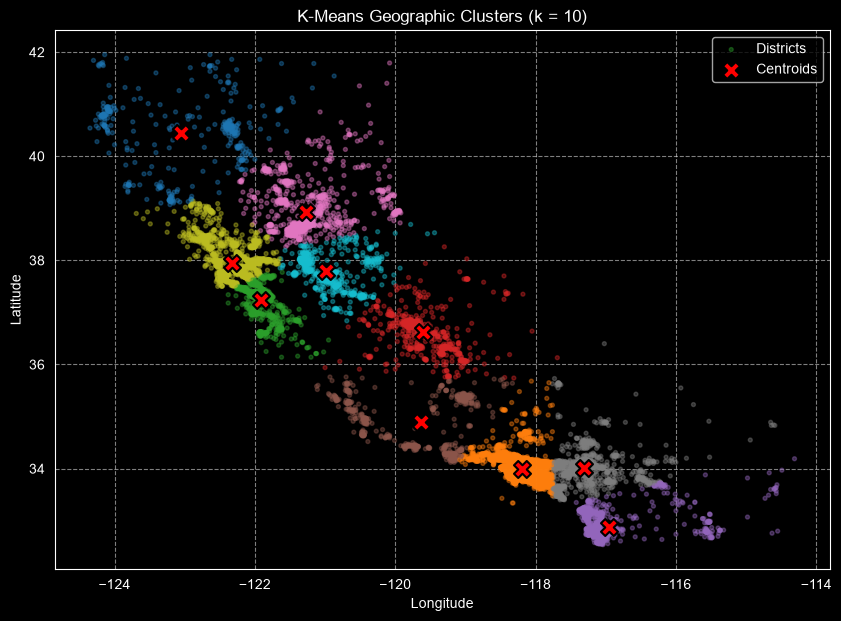

In [41]:
import matplotlib.pyplot as plt
labels = kmeans.predict(train_set[['latitude', 'longitude']])
centers = kmeans.cluster_centers_


plt.figure(figsize=(10, 7))

plt.scatter(
    x=train_set['longitude'],
    y=train_set['latitude'],
    c=labels,
    cmap='tab10',
    s=8,
    alpha=0.4,
    label='Districts'
)

plt.scatter(
    x=centers[:, 1],
    y=centers[:, 0],
    c='red',
    marker='X',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    label='Centroids'
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'K-Means Geographic Clusters (k = {len(centers)})')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Corelation analysis

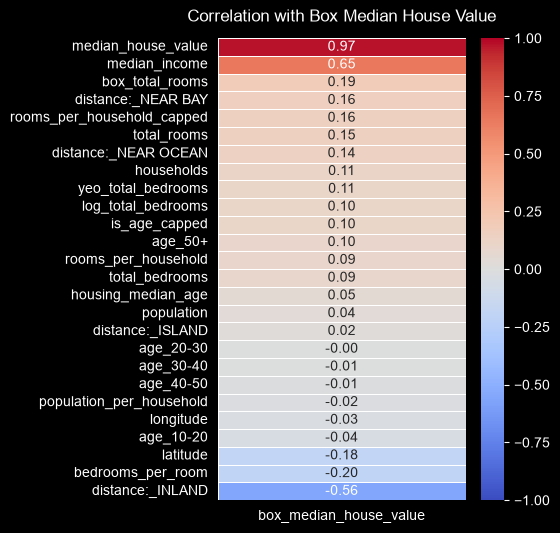

In [42]:
target_corr = train_set.corr(numeric_only=True)[['box_median_house_value']].drop('box_median_house_value')
target_corr = target_corr.sort_values(by='box_median_house_value', ascending=False)

plt.figure(figsize=(4, 6))
sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    cbar=True,
    linewidths=0.5
)
plt.title("Correlation with Box Median House Value", pad=12)
plt.show()

Conclusion: Both median_income and distance_INLAND are strong predictors of the target variable

In [43]:
from sklearn.feature_selection import mutual_info_regression
Y = train_set['box_median_house_value']
X = train_set.drop(columns=['box_median_house_value'])
mi_scores = mutual_info_regression(X, Y)

mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print(mi_series)

median_house_value            7.578685
longitude                     0.379752
latitude                      0.350034
median_income                 0.335984
distance:_INLAND              0.195372
bedrooms_per_room             0.109263
rooms_per_household           0.074384
rooms_per_household_capped    0.071120
population_per_household      0.064011
total_rooms                   0.036112
housing_median_age            0.030113
box_total_rooms               0.028546
households                    0.028472
total_bedrooms                0.026504
log_total_bedrooms            0.021018
yeo_total_bedrooms            0.020714
population                    0.018846
is_age_capped                 0.016134
distance:_NEAR BAY            0.011778
age_50+                       0.011678
age_30-40                     0.009037
distance:_NEAR OCEAN          0.008075
age_10-20                     0.007442
age_20-30                     0.002781
age_40-50                     0.001376
distance:_ISLAND         

Conclusion: Higher Mutual Information (MI) scores indicate a stronger dependency on the target variable, whereas features with scores near zero exhibit little to no predictive value.

# Feature selection

In [44]:
drop_cols = [
    'median_house_value',
    'age_10-20', 'age_20-30', 'age_30-40', 'age_40-50', 'age_50+',
    'distance:_ISLAND',
    'total_rooms',
    'rooms_per_household',
    'total_bedrooms',
    'log_total_bedrooms'
]

train_set_clean = train_set.drop(columns=drop_cols)


In [45]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 15712 entries, 17758 to 277
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   15712 non-null  float64
 1   latitude                    15712 non-null  float64
 2   housing_median_age          15712 non-null  float64
 3   total_rooms                 15712 non-null  float64
 4   total_bedrooms              15712 non-null  float64
 5   population                  15712 non-null  float64
 6   households                  15712 non-null  float64
 7   median_income               15712 non-null  float64
 8   median_house_value          15712 non-null  float64
 9   box_median_house_value      15712 non-null  float64
 10  log_total_bedrooms          15712 non-null  float64
 11  yeo_total_bedrooms          15712 non-null  float64
 12  box_total_rooms             15712 non-null  float64
 13  age_10-20                   15712 non-null  i

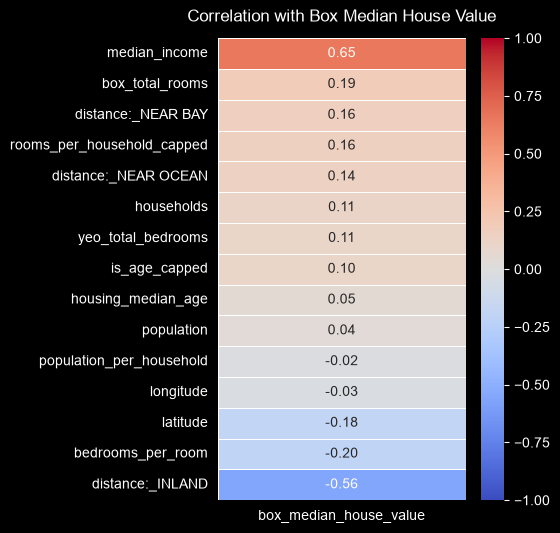

In [46]:
target_corr = train_set_clean.corr(numeric_only=True)[['box_median_house_value']].drop('box_median_house_value')
target_corr = target_corr.sort_values(by='box_median_house_value', ascending=False)

plt.figure(figsize=(4, 6))
sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    cbar=True,
    linewidths=0.5
)
plt.title("Correlation with Box Median House Value", pad=12)
plt.show()

In [47]:
train_set_clean = train_set_clean.drop(
    columns=['yeo_total_bedrooms', 'population'],
    errors='ignore'
)

In [48]:
train_set_clean['geo_cluster'] = labels
cluster_dummies = pd.get_dummies(
    train_set_clean['geo_cluster'],
    prefix='cluster',
    drop_first=True,
    dtype=int
)
train_set_clean = pd.concat([train_set_clean, cluster_dummies], axis=1)
train_set_clean = train_set_clean.drop(columns=['geo_cluster', 'latitude', 'longitude'])

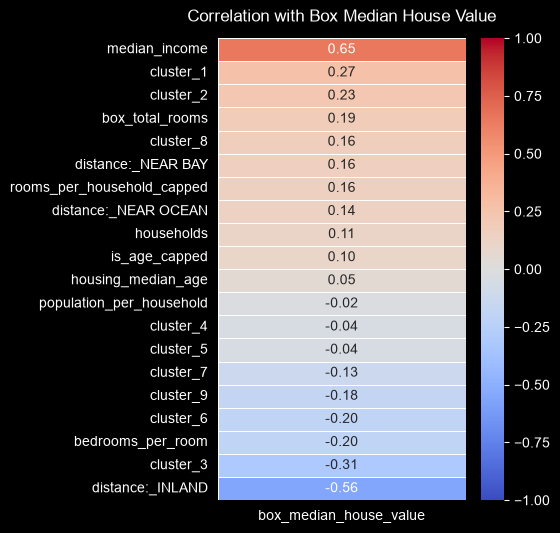

In [49]:
target_corr = train_set_clean.corr(numeric_only=True)[['box_median_house_value']].drop('box_median_house_value')
target_corr = target_corr.sort_values(by='box_median_house_value', ascending=False)

plt.figure(figsize=(4, 6))
sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    cbar=True,
    linewidths=0.5
)
plt.title("Correlation with Box Median House Value", pad=12)
plt.show()

In [50]:
train_set_clean.to_csv("data/processed/data.csv", index=False)